# Customer Churn Prediction
**CodSoft ML Internship** — Random Forest Classifier

This notebook uses the real churn dataset in the repo root: `Churn_Modelling.csv`.


In [23]:
# ============================================
# STEP 1: Import Required Libraries
# ============================================
import os
import warnings
warnings.filterwarnings('ignore')  # Suppress warning messages

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler      # Normalize numeric features
from sklearn.ensemble import RandomForestClassifier   # Our ML model

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,              # Overall correctness
    classification_report,       # Precision, Recall, F1-score
    confusion_matrix,            # Show True/False positives/negatives
    ConfusionMatrixDisplay       # Visualize confusion matrix
)

# Better visualizations
plt.rcParams.update({'figure.dpi': 110})
print('✅ All libraries imported successfully')


✅ All libraries imported successfully


## 📂 Load Dataset

In [ ]:
# ============================================
# STEP 2: Load the Real Churn Dataset
# ============================================

# Find the CSV file in the datasets folder (repo root/datasets/)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
file_path = os.path.join(repo_root, 'datasets', 'Churn_Modelling.csv')

print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)

# Select only the important columns we need for prediction
selected_columns = [
    'CreditScore',      # Customer's credit score
    'Geography',        # Country (France, Germany, Spain)
    'Gender',          # Male or Female
    'Age',             # Customer age
    'Tenure',          # Years as a customer
    'Balance',         # Account balance
    'NumOfProducts',   # Number of bank products
    'HasCrCard',       # Has credit card (1 = yes, 0 = no)
    'IsActiveMember',  # Active member (1 = yes, 0 = no)
    'EstimatedSalary', # Salary estimate
    'Exited'           # Target: Did customer leave? (1 = yes, 0 = no)
]

df = df[selected_columns].copy()

# Show dataset info
print(f"\n✅ Dataset loaded successfully")
print(f"Total customers: {len(df)}")
print(f"Total features: {len(df.columns) - 1}")
churn_percentage = df['Exited'].mean() * 100
print(f"Customers who left (churned): {churn_percentage:.2f}%")
print(f"\nFirst 5 rows of data:")
print(df.head())


Loading data from: d:\codsoft\Churn_Modelling.csv
Total customers: 10000
Total features: 10
Customers who left (churned): 20.37%

First 5 rows of data:
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


## 🔍 EDA

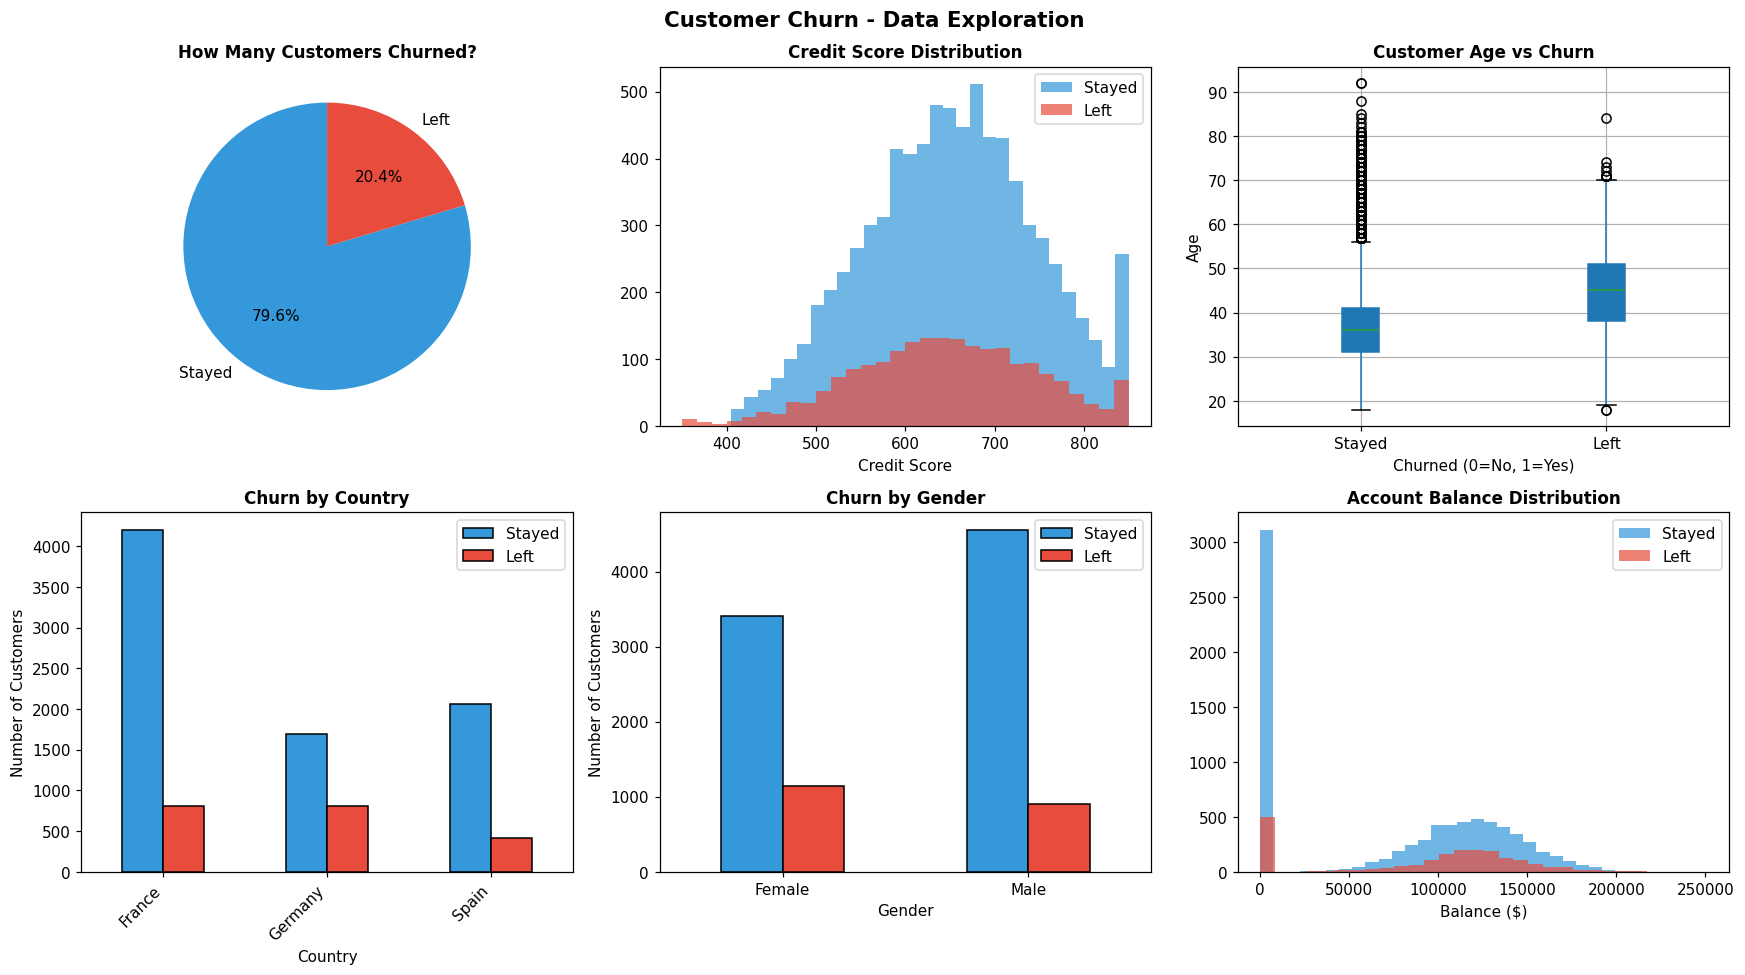

✅ Exploration visualizations saved as 'eda_overview.png'


In [25]:
# ============================================
# STEP 3: Explore the Data (EDA)
# ============================================
# Let's visualize different aspects of customer churn

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- Chart 1: Churn Distribution ---
# How many customers stayed vs left?
churn_counts = df['Exited'].value_counts()
axes[0, 0].pie(
    churn_counts.values,
    labels=['Stayed', 'Left'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90
)
axes[0, 0].set_title('How Many Customers Churned?', fontweight='bold', fontsize=11)

# --- Chart 2: Credit Score vs Churn ---
# Do customers with lower credit scores leave more often?
for churn_status, color, label in [(0, '#3498db', 'Stayed'), (1, '#e74c3c', 'Left')]:
    credit_scores = df[df['Exited'] == churn_status]['CreditScore']
    axes[0, 1].hist(credit_scores, bins=30, alpha=0.7, color=color, label=label)
axes[0, 1].set_title('Credit Score Distribution', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Credit Score')
axes[0, 1].legend()

# --- Chart 3: Age vs Churn ---
# Which age groups churn most?
df.boxplot(column='Age', by='Exited', ax=axes[0, 2], patch_artist=True)
axes[0, 2].set_title('Customer Age vs Churn', fontweight='bold', fontsize=11)
axes[0, 2].set_xlabel('Churned (0=No, 1=Yes)')
axes[0, 2].set_ylabel('Age')
plt.sca(axes[0, 2])
plt.xticks([1, 2], ['Stayed', 'Left'])

# --- Chart 4: Geography vs Churn ---
# Which countries have the most churn?
geo_churn = df.groupby(['Geography', 'Exited']).size().unstack(fill_value=0)
geo_churn.plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1, 0].set_title('Churn by Country', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Country')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].legend(['Stayed', 'Left'])
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Chart 5: Gender vs Churn ---
# Do men and women churn at different rates?
gender_churn = df.groupby(['Gender', 'Exited']).size().unstack(fill_value=0)
gender_churn.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1, 1].set_title('Churn by Gender', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].legend(['Stayed', 'Left'])
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=0)

# --- Chart 6: Balance vs Churn ---
# Do richer customers stay longer?
for churn_status, color, label in [(0, '#3498db', 'Stayed'), (1, '#e74c3c', 'Left')]:
    balances = df[df['Exited'] == churn_status]['Balance']
    axes[1, 2].hist(balances, bins=30, alpha=0.7, color=color, label=label)
axes[1, 2].set_title('Account Balance Distribution', fontweight='bold', fontsize=11)
axes[1, 2].set_xlabel('Balance ($)')
axes[1, 2].legend()

plt.suptitle('Customer Churn - Data Exploration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=120)
plt.show()

print("✅ Exploration visualizations saved as 'eda_overview.png'")


## 🤖 Preprocessing & Training

In [32]:
# ============================================
# STEP 4: Prepare Data & Train the Model
# ============================================

print("\n--- Preparing Data ---")

# Separate features (X) from target (y)
feature_cols = [col for col in df.columns if col != 'Exited']
df_prepared = df.copy()


# Identify numeric and categorical columns
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                    'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_columns = [col for col in feature_cols if col not in numeric_columns]

for col in categorical_columns:
    df_prepared[col] = pd.Categorical(df_prepared[col]).codes

scaler = StandardScaler()
df_prepared[numeric_columns] = scaler.fit_transform(df_prepared[numeric_columns])

X = df_prepared[feature_cols].values 
y = df_prepared['Exited'].values   


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,           # Use 20% for testing
    random_state=42,          # For reproducibility
    stratify=y                # Keep churn ratio same in train/test
)


# Step 4: Create and train the Random Forest model
print("\n--- Training Random Forest Model ---")
model = RandomForestClassifier(
    n_estimators=200,       
    class_weight='balanced',  # Handle class imbalance
    max_depth=15,             # Tree depth limit
    min_samples_leaf=2,       # Minimum samples per leaf
    random_state=42,          # For reproducibility
    n_jobs=-1                 # Use all processors
)

model.fit(X_train, y_train)  
y_pred = model.predict(X_test)  


print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\n Accuracy: {accuracy:.2f}%")
print(f"   (Out of 100 customers, model correctly predicts ~{accuracy:.0f})\n")

print("Detailed Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Stayed', 'Left'],
    zero_division=0
))



--- Preparing Data ---

--- Training Random Forest Model ---

MODEL PERFORMANCE

 Accuracy: 85.50%
   (Out of 100 customers, model correctly predicts ~86)

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91      1593
        Left       0.68      0.54      0.60       407

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.85      0.85      0.85      2000



## 📈 Evaluation


--- Model Evaluation ---


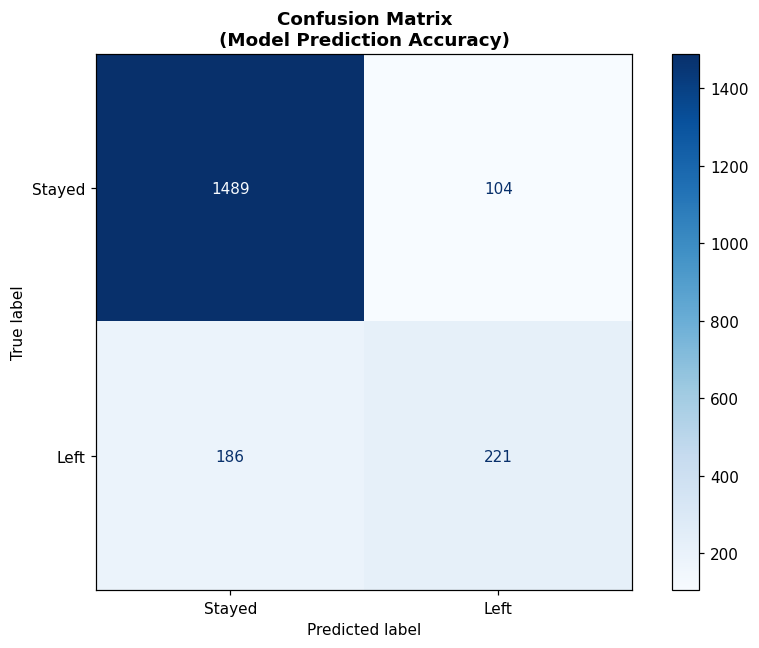


📊 Understanding the Confusion Matrix:
True Negatives (TN):   1489  - Correctly predicted 'Stayed'
False Positives (FP):   104  - Incorrectly predicted 'Left'
False Negatives (FN):   186  - Incorrectly predicted 'Stayed'
True Positives (TP):    221  - Correctly predicted 'Left'


In [33]:

print("\n--- Model Evaluation ---")

# Create confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    cm,
    display_labels=['Stayed', 'Left']
).plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title('Confusion Matrix\n(Model Prediction Accuracy)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('evaluation.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📊 Understanding the Confusion Matrix:")
print(f"True Negatives (TN):  {cm[0, 0]:5d}  - Correctly predicted 'Stayed'")
print(f"False Positives (FP): {cm[0, 1]:5d}  - Incorrectly predicted 'Left'")
print(f"False Negatives (FN): {cm[1, 0]:5d}  - Incorrectly predicted 'Stayed'")
print(f"True Positives (TP):  {cm[1, 1]:5d}  - Correctly predicted 'Left'")




--- Analyzing Feature Importance ---


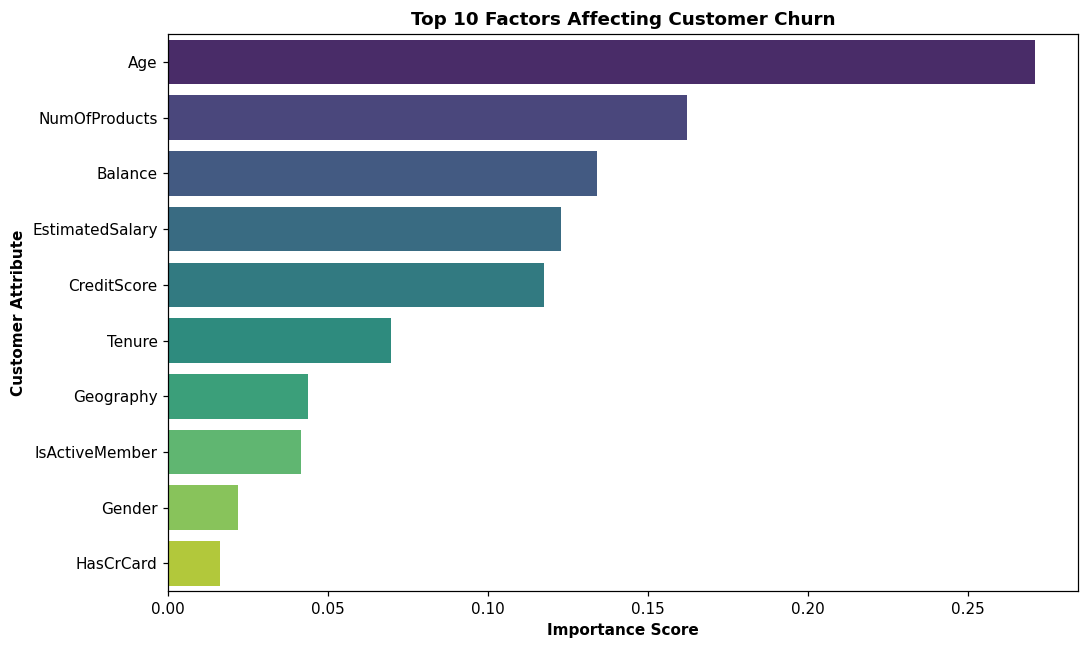


TOP 5 FACTORS AFFECTING CHURN
1. Age                  -  27.09%
2. NumOfProducts        -  16.22%
3. Balance              -  13.42%
4. EstimatedSalary      -  12.28%
5. CreditScore          -  11.75%


In [35]:


print("\n--- Analyzing Feature Importance ---")

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
})

# Sort by importance (most important first)
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis',
    ax=ax
)
ax.set_title('Top 10 Factors Affecting Customer Churn', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_ylabel('Customer Attribute', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

# Print top 5 churn drivers
print("\n" + "="*50)
print("TOP 5 FACTORS AFFECTING CHURN")
print("="*50)
top_5 = feature_importance_df.head(5)
for idx, (feature, importance) in enumerate(zip(top_5['Feature'], top_5['Importance']), 1):
    percentage = importance * 100
    print(f"{idx}. {feature:20s} - {percentage:6.2f}%")

